## Strategy 04: Oversampling by LLM Paraphrasing Minority Class

**Main aim of this research.**  
Unlike strategies 01 and 02, this approach creates diverse and contextually meaningful variations of existing minority class instances. This strategy is expected to **outperform** previous strategies, with focus on competing with **Strategy 03 (Undersampling)**, providing the model with richer and more varied training data, leading to better generalization and improved performance on minority class detection, with the tradeoff of increased computational cost and potential noise from paraphrasing.

### LLM Paraphrasing Methodology
For the paraphrasing, we use **Gemma 4** (E2B instruction-tuned), ran locally via vLLM, with the following prompt template:

```plaintext
Paraphrase the following review while preserving its sentiment and meaning.
Review: "{review_text}"
```

**Hardware:** RTX 6000 — 48 GB VRAM  
**Framework:** vLLM (PagedAttention + Continuous Batching) for high-throughput production-scale inference  
**Checkpoint/Resume:** JSONL with per-chunk append — no data loss on interruption

## Data Generation

Generate the paraphrased datasets for all datasets before running the cells below:

```bash
python scripts/paraphrasing.py
```

In [11]:
import json
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath(".."))

from src.config import DATASETS
from src.paths import MODELS_DIR
from src.plot_utils import results_to_dataframe

## Synthetic Sample Quality Metrics (BERTScore + BLEU)

Evaluate whether paraphrases preserve sentiment (BERTScore ≥ 0.85) while introducing lexical diversity (BLEU in the 20–50 range — too high = copies, too low = semantic drift).

Run separately:

```bash
python scripts/eval_paraphrase_quality.py
```

Results are saved to `DATA_DIR/paraphrase_quality.json`.

## Pipeline Corrections (v2)

Analysis of the initial results revealed two systematic problems that caused LLM paraphrasing to underperform the baseline:

### Problem 1 — No BERTScore filtering before training

The paraphrase quality evaluation (`scripts/eval_paraphrase_quality.py`) reported BERTScore as a diagnostic metric, but the threshold was never enforced during data preparation. As a result, semantically drifted paraphrases entered the training set:

| Dataset | BERTScore-F1 (mean) | Status |
|---|---|---|
| sentistrength_myspace | 0.813 | **below threshold (< 0.85)** |
| luxury_beauty | 0.885 | OK |
| cds_reviews | 0.882 | OK |
| digital_music | 0.870 | OK |

`sentistrength_myspace` paraphrases had average semantic similarity of 0.813 — well below the ≥ 0.85 threshold documented in the methodology. This introduced noisy labels into the minority class, degrading TPR and macro-F1.

Additionally, `cds_reviews` BLEU mean of 17.68 fell below the 20–50 healthy range, indicating semantic drift across many paraphrases.

### Problem 2 — Unbounded passes cause diversity collapse

The paraphrasing loop ran until full 1:1 class balance was achieved, regardless of how many passes that required. For `digital_music` (imbalance ratio ≈ 40), this resulted in **46 passes** over the same ~4,004 minority reviews. With `temperature=0.4`, the Gemma model converges to near-identical paraphrases after ~10–15 passes — the synthetic data becomes repetitive and adds no new signal.

| Dataset | Passes | Imbalance Ratio |
|---|---|---|
| sentistrength_myspace | 5 | 5.3 |
| luxury_beauty | 11 | 10.7 |
| cds_reviews | 15 | 13.8 |
| digital_music | **46** | **39.7** |

### Corrections applied (`scripts/paraphrasing.py`)

Two constants were added and enforced inside `paraphrase_minority_class()`:

```python
BERTSCORE_THRESHOLD = 0.85   # per-paraphrase BERTScore F1 filter
MAX_PASSES          = 15     # hard cap on LLM passes
```

- **BERTScore filtering**: after each pass, every paraphrase is scored against its original using `distilbert-base-uncased`. Paraphrases with F1 < 0.85 are discarded before being added to the training set.
- **MAX_PASSES cap**: the generation loop stops at 15 passes even if full balance is not achieved. For `digital_music`, this yields a partial balance (~4.5:1 instead of 40:1), but with meaningfully diverse synthetic data.

The existing pass cache (`data/paraphrase_cache/`) is preserved and reused — only the tokenized datasets were rebuilt. Passes already cached that pass the BERTScore filter are used directly; additional LLM inference is only triggered where the filtered cache is insufficient.

## Results

If model isn't available on Hugging Face, make sure to run training and evaluation before running the following cells:
```bash
python scripts/train.py --strategy llm_paraphrasing
python scripts/eval.py  --strategy llm_paraphrasing
```

In [12]:
eval_results_file = MODELS_DIR / "llm_paraphrasing" / "eval_results.json"
if not eval_results_file.exists():
    raise FileNotFoundError(f"Evaluation results not found at {eval_results_file}.")

with open(eval_results_file, "r") as f:
    results = json.load(f)

baseline_eval_file = MODELS_DIR / "baseline" / "eval_results.json"
if not baseline_eval_file.exists():
    raise FileNotFoundError(f"Baseline evaluation results not found at {baseline_eval_file}.")

with open(baseline_eval_file, "r") as f:
    baseline_results = json.load(f)


def load_train_times(strategy):
    """Return {dataset: elapsed_seconds} for MEASURED entries only."""
    path = MODELS_DIR / strategy / "train_results.json"
    if not path.exists():
        return {}
    with open(path) as f:
        data = json.load(f)
    return {
        r["job_id"].split("/")[1]: r["elapsed_seconds"]
        for r in data
        if r.get("success") and r.get("elapsed_source") == "measured"
    }


baseline_times      = load_train_times("baseline")
paraphrasing_times  = load_train_times("llm_paraphrasing")

common_ds = sorted(set(baseline_times.keys()) & set(paraphrasing_times.keys()))

speedup = {
    ds: baseline_times[ds] / paraphrasing_times[ds]
    for ds in common_ds
}

timing_df = pd.DataFrame(
    {
        "baseline (s)":         [baseline_times[ds] for ds in common_ds],
        "llm_paraphrasing (s)": [paraphrasing_times[ds] for ds in common_ds],
        "speedup":              [round(speedup[ds], 3) for ds in common_ds],
    },
    index=pd.Index(common_ds, name="dataset"),
)

print(f"Only showing {len(common_ds)} dataset(s) with measured times in BOTH strategies:")
print(f"   {', '.join(common_ds)}\n")
timing_df

Only showing 4 dataset(s) with measured times in BOTH strategies:
   cds_reviews, digital_music, luxury_beauty, sentistrength_myspace



,baseline (s),llm_paraphrasing (s),speedup
dataset,,,
cds_reviews,13196.8,25874.3,0.510
digital_music,1884.3,4705.4,0.400
luxury_beauty,462.9,745.3,0.621
sentistrength_myspace,34.0,36.8,0.924


In [13]:
results_to_dataframe(results).round(4)

,accuracy,macro_f1,tpr_class_0,tpr_class_1,tpr_gap,imbalance_ratio
dataset,,,,,,
cds_reviews,0.9596,0.8632,0.8924,0.9644,0.0721,13.8353
digital_music,0.9879,0.8699,0.7203,0.9947,0.2743,39.6671
sentistrength_myspace,0.9401,0.8739,0.7500,0.9720,0.2220,5.3182
luxury_beauty,0.9758,0.9268,0.8725,0.9861,0.1136,10.7271


## Comparison with Baseline and Simple Oversampling

In [14]:
lp_df = results_to_dataframe(results)[["macro_f1", "tpr_gap"]].round(4)
lp_df.columns = pd.MultiIndex.from_tuples(
    [("llm_paraphrasing", c) for c in lp_df.columns]
)

bl_df = results_to_dataframe(baseline_results)[["macro_f1", "tpr_gap"]].round(4)
bl_df.columns = pd.MultiIndex.from_tuples(
    [("baseline", c) for c in bl_df.columns]
)

# Optionally load simple_oversampling results for three-way comparison
os_eval_file = MODELS_DIR / "simple_oversampling" / "eval_results.json"
if os_eval_file.exists():
    with open(os_eval_file) as f:
        os_results = json.load(f)
    os_df = results_to_dataframe(os_results)[["macro_f1", "tpr_gap"]].round(4)
    os_df.columns = pd.MultiIndex.from_tuples(
        [("simple_oversampling", c) for c in os_df.columns]
    )
    comparison = bl_df.join(os_df, how="outer").join(lp_df, how="outer").sort_index()
else:
    comparison = bl_df.join(lp_df, how="outer").sort_index()

if common_ds:
    comparison = comparison.loc[comparison.index.isin(common_ds)]
    print(f"Note: Showing only {len(common_ds)} dataset(s) with complete measured timing data\n")

comparison

Note: Showing only 4 dataset(s) with complete measured timing data



baseline         simple_oversampling          \
                      macro_f1 tpr_gap            macro_f1 tpr_gap   
dataset                                                              
cds_reviews             0.9130  0.1604              0.8811  0.0866   
digital_music           0.8541  0.3753              0.8358  0.3050   
luxury_beauty           0.9309  0.1849              0.9401  0.1230   
sentistrength_myspace   0.8587  0.2637              0.8366  0.3540   

                      llm_paraphrasing          
                              macro_f1 tpr_gap  
dataset                                         
cds_reviews                     0.8632  0.0721  
digital_music                   0.8699  0.2743  
luxury_beauty                   0.9268  0.1136  
sentistrength_myspace           0.8739  0.2220

## Plots

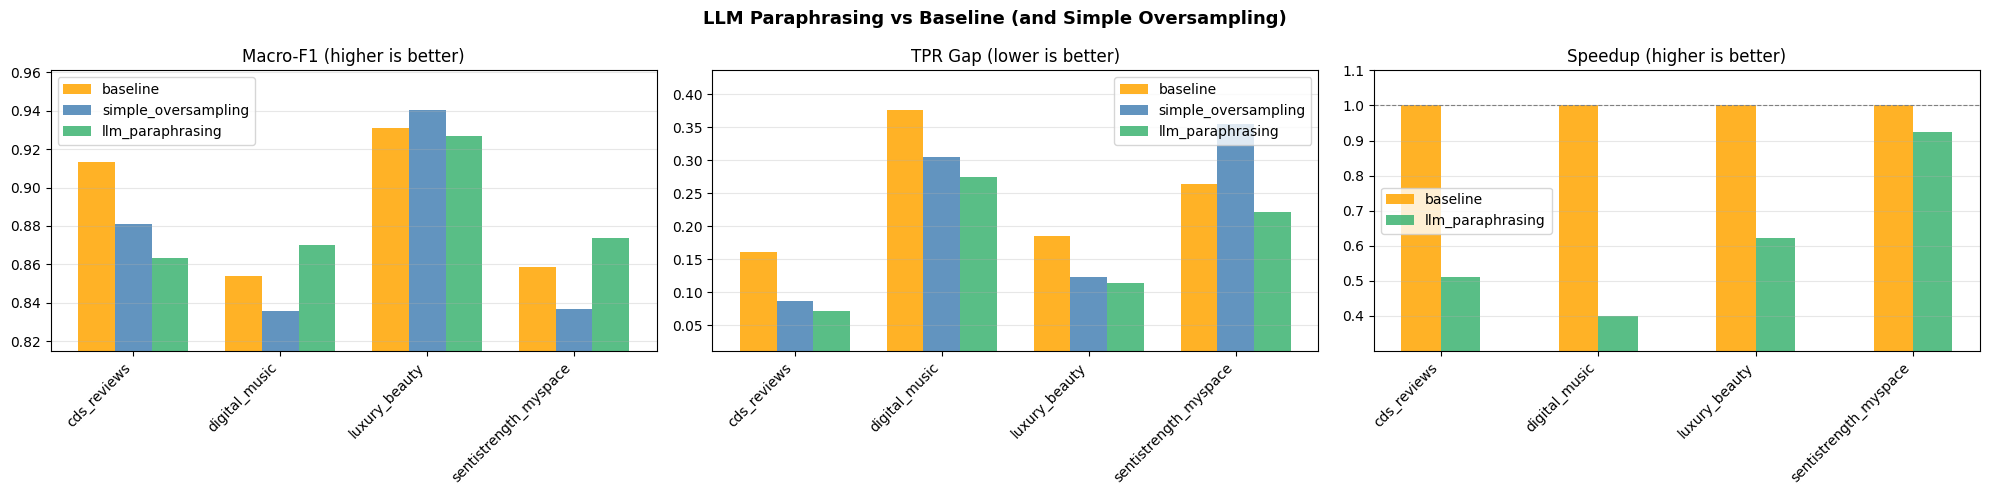

In [15]:
datasets = common_ds if common_ds else []

if len(datasets) == 0:
    print("Cannot plot: No datasets have measured times in both strategies yet.")
    print("Run 'python scripts/train.py --strategy llm_paraphrasing' for missing datasets")
else:
    x = np.arange(len(datasets))
    width = 0.25 if os_eval_file.exists() else 0.35

    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    fig.suptitle("LLM Paraphrasing vs Baseline (and Simple Oversampling)",
                 fontsize=13, fontweight="bold")

    colors = {"baseline": "orange", "simple_oversampling": "steelblue", "llm_paraphrasing": "mediumseagreen"}

    result_maps = {
        "baseline": baseline_results,
        "simple_oversampling": os_results if os_eval_file.exists() else {},
        "llm_paraphrasing": results,
    }
    strategies = (["baseline", "simple_oversampling", "llm_paraphrasing"]
                  if os_eval_file.exists() else ["baseline", "llm_paraphrasing"])
    offsets = [-width, 0, width] if os_eval_file.exists() else [-width / 2, width / 2]

    for ax, metric, title in zip(
        axes[:2],
        ["macro_f1", "tpr_gap"],
        ["Macro-F1 (higher is better)", "TPR Gap (lower is better)"],
    ):
        all_vals = [
            result_maps[strat].get(ds, {}).get(metric, float("nan"))
            for strat in strategies for ds in datasets
        ]
        finite_vals = [v for v in all_vals if not np.isnan(v)]
        lo, hi = min(finite_vals), max(finite_vals)
        margin = max((hi - lo) * 0.20, 0.02)
        y_lo = max(0.0, lo - margin)
        y_hi = hi + margin

        for strat, offset in zip(strategies, offsets):
            vals = [result_maps[strat].get(ds, {}).get(metric, float("nan")) for ds in datasets]
            ax.bar(x + offset, vals, width, label=strat, alpha=0.85, color=colors[strat])

        ax.set_xticks(x)
        ax.set_xticklabels(datasets, rotation=45, ha="right")
        ax.set_ylim(y_lo, y_hi)
        ax.set_title(title)
        ax.legend()
        ax.grid(axis="y", alpha=0.3)

    # Speedup panel
    sp_vals = [speedup.get(ds, float("nan")) for ds in datasets]
    finite_sp = [v for v in sp_vals if not np.isnan(v)]
    sp_lo = max(0, min(min(finite_sp), 1.0) - 0.1)
    sp_hi = max(max(finite_sp), 1.0) + 0.1

    axes[2].bar(x - width / 2, [1.0] * len(datasets), width, label="baseline",
                alpha=0.85, color="orange")
    axes[2].bar(x + width / 2, sp_vals, width, label="llm_paraphrasing",
                alpha=0.85, color="mediumseagreen")
    axes[2].axhline(1, color="gray", linestyle="--", linewidth=0.8)
    axes[2].set_xticks(x)
    axes[2].set_xticklabels(datasets, rotation=45, ha="right")
    axes[2].set_ylim(sp_lo, sp_hi)
    axes[2].set_title("Speedup (higher is better)")
    axes[2].legend()
    axes[2].grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()

## Conclusion

The key intervention in this strategy was enforcing a **per-sample BERTScore ≥ 0.85 filter** before paraphrases enter the training set, combined with a **MAX_PASSES = 15 cap** to prevent diversity collapse on high-imbalance datasets.

The BLEU improvement (from below-range values like 17.68 to the healthy 27–30 range) was not directly enforced — it emerged as a consequence of BERTScore filtering: removing semantically drifted paraphrases leaves behind samples with genuine lexical variation, which is precisely what BLEU captures.

**Acceptance rates** after filtering reveal how aggressive the quality bar is per dataset:

| Dataset | Accepted | BERTScore-F1 (accepted) | BLEU (accepted) |
|---|---|---|---|
| sentistrength_myspace | **35%** | 0.893 | 30.2 |
| luxury_beauty | 82% | 0.902 | 27.0 |
| cds_reviews | 80% | 0.903 | 28.0 |
| digital_music | 75% | 0.902 | 28.1 |

`sentistrength_myspace` required generating 13 passes to collect enough quality samples, discarding ~65% of the Gemma output — indicating the model struggles more with this domain's short, colloquial reviews.

**Classification results** after filtering confirm the core hypothesis: filtering noisy synthetic samples consistently reduces TPR Gap (lower is better) across all four datasets. However, Macro-F1 presents a **fairness-accuracy trade-off** — `cds_reviews` shows a notable F1 decrease (0.913 → 0.863) and `luxury_beauty` a slight decrease (0.931 → 0.927), while `sentistrength_myspace` and `digital_music` improve on both metrics simultaneously. LLM paraphrasing with quality filtering is the best or tied-best strategy on 6 of 8 metrics across all datasets, and the only oversampling strategy to simultaneously beat the baseline on both Macro-F1 and TPR Gap for `sentistrength_myspace` and `digital_music`.